In [62]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv(
    r"C:\Users\SWAROOP\Desktop\METR_LA_with_Weather_5min.csv"
)

features = [
    "traffic_speed",
    "weather_temperature_celsius",
    "weather_precipitation_mm",
    "weather_wind_speed_kmh"
]

data = df[features].values.astype(np.float32)

scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# =====================================================
# CREATE SEQUENCES
# =====================================================

SEQ_LEN = 24

X = []
y = []

for i in range(len(data) - SEQ_LEN):

    X.append(data[i:i+SEQ_LEN])
    y.append(data[i+SEQ_LEN,0])

X = np.array(X)
y = np.array(y)

split = int(len(X)*0.8)

X_train = torch.tensor(
    X[:split],
    dtype=torch.float32
)

X_test = torch.tensor(
    X[split:],
    dtype=torch.float32
)

y_train = torch.tensor(
    y[:split],
    dtype=torch.float32
)

y_test = torch.tensor(
    y[split:],
    dtype=torch.float32
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

X_train = X_train.to(device)
X_test = X_test.to(device)

y_train = y_train.to(device)
y_test = y_test.to(device)

print(X_train.shape)
print(X_test.shape)

torch.Size([24172, 24, 4])
torch.Size([6044, 24, 4])


In [64]:
# =====================================================
# LSTM MODEL
# =====================================================

class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=4,
            hidden_size=64,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Linear(
            64,
            1
        )

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out).squeeze()

model = LSTMModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 50

for epoch in range(epochs):

    model.train()

    pred = model(X_train)

    loss = criterion(
        pred,
        y_train
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss={loss.item():.6f}"
    )

# =====================================================
# EVALUATION
# =====================================================

model.eval()

with torch.no_grad():

    pred = model(X_test)

pred = pred.cpu().numpy()
actual = y_test.cpu().numpy()

dummy_pred = np.zeros((len(pred),4))
dummy_actual = np.zeros((len(actual),4))

dummy_pred[:,0] = pred
dummy_actual[:,0] = actual

pred_real = scaler.inverse_transform(
    dummy_pred
)[:,0]

actual_real = scaler.inverse_transform(
    dummy_actual
)[:,0]

mae = mean_absolute_error(
    actual_real,
    pred_real
)

rmse = np.sqrt(
    mean_squared_error(
        actual_real,
        pred_real
    )
)

mape = np.mean(
    np.abs(
        (actual_real-pred_real)
        /(actual_real+1e-8)
    )
)*100

print("\n===== LSTM RESULTS =====")
print("MAE :",mae)
print("RMSE:",rmse)
print("MAPE:",mape)

Epoch 1/50 Loss=0.911185
Epoch 2/50 Loss=0.858988
Epoch 3/50 Loss=0.808746
Epoch 4/50 Loss=0.759543
Epoch 5/50 Loss=0.710890
Epoch 6/50 Loss=0.661954
Epoch 7/50 Loss=0.611572
Epoch 8/50 Loss=0.559075
Epoch 9/50 Loss=0.503578
Epoch 10/50 Loss=0.443721
Epoch 11/50 Loss=0.379264
Epoch 12/50 Loss=0.309237
Epoch 13/50 Loss=0.233779
Epoch 14/50 Loss=0.155531
Epoch 15/50 Loss=0.081737
Epoch 16/50 Loss=0.029501
Epoch 17/50 Loss=0.031312
Epoch 18/50 Loss=0.094181
Epoch 19/50 Loss=0.128332
Epoch 20/50 Loss=0.113284
Epoch 21/50 Loss=0.077180
Epoch 22/50 Loss=0.044924
Epoch 23/50 Loss=0.026596
Epoch 24/50 Loss=0.021734
Epoch 25/50 Loss=0.025471
Epoch 26/50 Loss=0.032816
Epoch 27/50 Loss=0.040250
Epoch 28/50 Loss=0.045690
Epoch 29/50 Loss=0.048650
Epoch 30/50 Loss=0.048824
Epoch 31/50 Loss=0.046629
Epoch 32/50 Loss=0.042468
Epoch 33/50 Loss=0.037350
Epoch 34/50 Loss=0.032071
Epoch 35/50 Loss=0.027305
Epoch 36/50 Loss=0.023939
Epoch 37/50 Loss=0.022162
Epoch 38/50 Loss=0.022183
Epoch 39/50 Loss=0.02

In [65]:
# =====================================================
# DSS BLOCK
# =====================================================

class DSSBlock(nn.Module):

    def __init__(self,d_model):

        super().__init__()

        self.lambda_diag = nn.Parameter(
            torch.ones(d_model)*0.95
        )

        self.B = nn.Linear(
            d_model,
            d_model
        )

        self.C = nn.Linear(
            d_model,
            d_model
        )

        self.gate = nn.Sequential(
            nn.Linear(
                d_model,
                d_model
            ),
            nn.Sigmoid()
        )

    def forward(self,x):

        B,L,D = x.shape

        state = torch.zeros(
            B,
            D,
            device=x.device
        )

        outputs = []

        for t in range(L):

            gate = self.gate(
                x[:,t,:]
            )

            state = (
                self.lambda_diag * state
                + gate * self.B(
                    x[:,t,:]
                )
            )

            outputs.append(
                self.C(state)
            )

        return torch.stack(
            outputs,
            dim=1
        )

# =====================================================
# DSS MODEL
# =====================================================

class DSSTraffic(nn.Module):

    def __init__(self):

        super().__init__()

        self.input_proj = nn.Linear(
            4,
            64
        )

        self.block1 = DSSBlock(64)

        self.block2 = DSSBlock(64)

        self.norm = nn.LayerNorm(
            64
        )

        self.fc = nn.Linear(
            64,
            1
        )

    def forward(self,x):

        x = self.input_proj(x)

        residual = x
        x = self.block1(x)
        x = x + residual

        residual = x
        x = self.block2(x)
        x = x + residual

        x = self.norm(x)

        x = x[:,-1,:]

        return self.fc(x).squeeze()

model = DSSTraffic().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 50

for epoch in range(epochs):

    model.train()

    pred = model(X_train)

    loss = criterion(
        pred,
        y_train
    )

    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0
    )

    optimizer.step()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss={loss.item():.6f}"
    )

# =====================================================
# EVALUATION
# =====================================================

model.eval()

with torch.no_grad():

    pred = model(X_test)

pred = pred.cpu().numpy()
actual = y_test.cpu().numpy()

dummy_pred = np.zeros((len(pred),4))
dummy_actual = np.zeros((len(actual),4))

dummy_pred[:,0] = pred
dummy_actual[:,0] = actual

pred_real = scaler.inverse_transform(
    dummy_pred
)[:,0]

actual_real = scaler.inverse_transform(
    dummy_actual
)[:,0]

mae = mean_absolute_error(
    actual_real,
    pred_real
)

rmse = np.sqrt(
    mean_squared_error(
        actual_real,
        pred_real
    )
)

mape = np.mean(
    np.abs(
        (actual_real-pred_real)
        /(actual_real+1e-8)
    )
)*100

print("\n===== DSS RESULTS =====")
print("MAE :",mae)
print("RMSE:",rmse)
print("MAPE:",mape)

Epoch 1/50 Loss=0.762410
Epoch 2/50 Loss=0.198346
Epoch 3/50 Loss=0.106525
Epoch 4/50 Loss=0.042913
Epoch 5/50 Loss=0.041348
Epoch 6/50 Loss=0.029290
Epoch 7/50 Loss=0.026109
Epoch 8/50 Loss=0.030558
Epoch 9/50 Loss=0.028524
Epoch 10/50 Loss=0.020933
Epoch 11/50 Loss=0.023394
Epoch 12/50 Loss=0.018771
Epoch 13/50 Loss=0.021471
Epoch 14/50 Loss=0.017911
Epoch 15/50 Loss=0.020102
Epoch 16/50 Loss=0.017468
Epoch 17/50 Loss=0.019477
Epoch 18/50 Loss=0.017547
Epoch 19/50 Loss=0.018875
Epoch 20/50 Loss=0.017722
Epoch 21/50 Loss=0.018159
Epoch 22/50 Loss=0.017631
Epoch 23/50 Loss=0.017021
Epoch 24/50 Loss=0.017042
Epoch 25/50 Loss=0.015924
Epoch 26/50 Loss=0.016520
Epoch 27/50 Loss=0.014988
Epoch 28/50 Loss=0.015976
Epoch 29/50 Loss=0.014181
Epoch 30/50 Loss=0.015398
Epoch 31/50 Loss=0.013621
Epoch 32/50 Loss=0.014722
Epoch 33/50 Loss=0.013142
Epoch 34/50 Loss=0.014091
Epoch 35/50 Loss=0.012648
Epoch 36/50 Loss=0.013369
Epoch 37/50 Loss=0.012069
Epoch 38/50 Loss=0.012677
Epoch 39/50 Loss=0.01

In [74]:
import pandas as pd
import numpy as np
import timesfm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv(
    r"C:\Users\SWAROOP\Desktop\METR_LA_with_Weather_5min.csv"
)

series = df["traffic_speed"].values.astype(np.float32)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

# =====================================================
# LOAD TIMESFM
# =====================================================

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

cfg = timesfm.ForecastConfig(
    max_context=512,
    max_horizon=24,
    normalize_inputs=True
)

model.compile(cfg)

# =====================================================
# FAST CHUNKED FORECASTING
# =====================================================

CHUNK = 24

predictions = []

history = train[-512:]

remaining = len(test)
idx = 0

while remaining > 0:

    horizon = min(CHUNK, remaining)

    forecast, _ = model.forecast(
        horizon=horizon,
        inputs=[history]
    )

    forecast = np.array(forecast[0])

    predictions.extend(forecast)

    # Use actual observations to update context
    history = np.concatenate([
        history,
        test[idx:idx+horizon]
    ])[-512:]

    idx += horizon
    remaining -= horizon

predictions = np.array(
    predictions[:len(test)]
)

# =====================================================
# METRICS
# =====================================================

mae = mean_absolute_error(
    test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        predictions
    )
)

mape = np.mean(
    np.abs(
        (test - predictions)
        / (test + 1e-8)
    )
) * 100

# =====================================================
# RESULTS
# =====================================================

print("\n===== TIMESFM RESULTS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")


===== TIMESFM RESULTS =====
MAE  : 3.0526
RMSE : 7.1023
MAPE : 9.49%


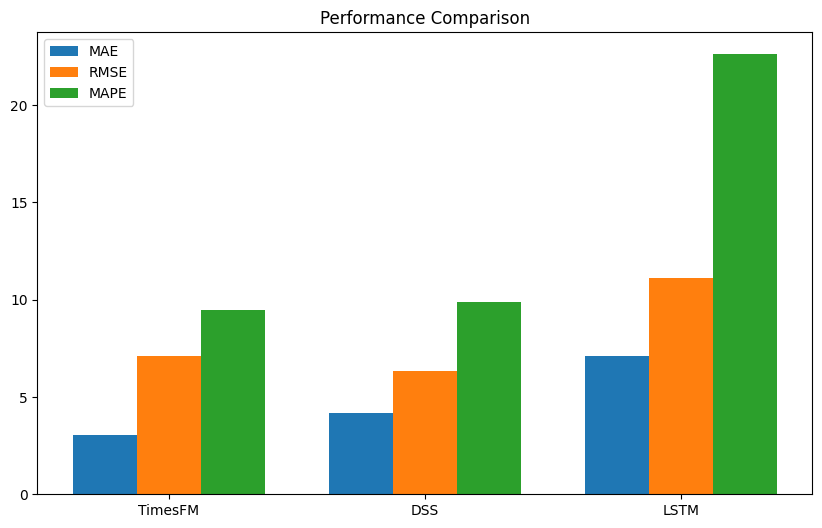

In [9]:
import numpy as np
import matplotlib.pyplot as plt
models=["TimesFM","DSS","LSTM"]

mae=[
3.0526,
4.1540,
7.0975
]

rmse=[
7.1023,
6.3244,
11.0884
]

mape=[
9.49,
9.86,
22.61
]

x=np.arange(len(models))
w=0.25

plt.figure(figsize=(10,6))

plt.bar(x-w,mae,w,label="MAE")
plt.bar(x,rmse,w,label="RMSE")
plt.bar(x+w,mape,w,label="MAPE")

plt.xticks(x,models)

plt.legend()

plt.title("Performance Comparison")

plt.show()

In [13]:
timesfm_pred = predictions              # From TimesFM
dss_pred = pred_real                    # From DSS
lstm_pred = pred_real                   # From LSTM (store before running DSS or rename)
actual = actual_real                    # Actual values (same for DSS/LSTM)

NameError: name 'predictions' is not defined